In [1]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import OneHotEncoder


## Dataset loading

In [2]:
# Define a custom transform for binarization
class Binarize(object):
    def __init__(self, threshold=0.5):
        self.threshold = threshold

    def __call__(self, tensor):
        return (tensor > self.threshold).float()

# Compose transforms: ToTensor converts PIL image to [0,1] float tensor, Binarize thresholds it
transform = transforms.Compose([
    transforms.ToTensor(),
    Binarize(threshold=0.5)  # You can adjust the threshold if needed
])

# Load MNIST dataset with binarization applied
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
trainset = DataLoader(train_dataset, batch_size=64, shuffle=True)
testset = DataLoader(test_dataset, batch_size=64, shuffle=False)

Analizing dataset...


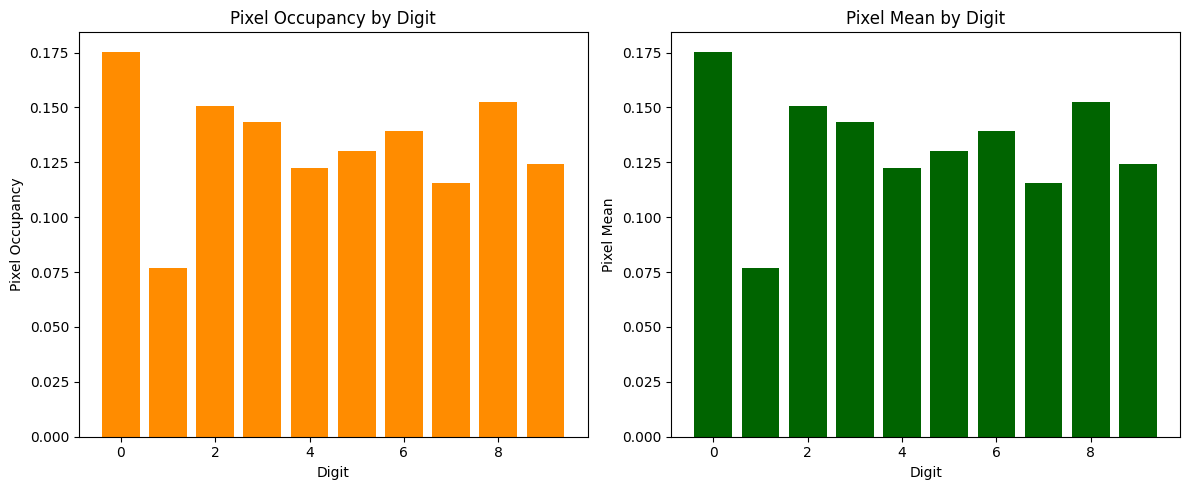

In [3]:
data = {}       # per digit dictionary

for digit in range(10):
    data[digit] = {
        'Pixel Mean Sum': 0.0,
        'Pixel Occupancy Sum': 0.0,
        'Count': 0
    }

print("Analizing dataset...")
for images, lbls in trainset:
    # flatten (batch, 1, 28, 28) -> (batch, 784)
    flat = images.view(images.size(0), -1)
    
    # 1- Get pixel mean values of image
    means = flat.mean(dim=1)
    # 2- get % of pixels that the digit occupy
    occupancy = flat.sum(dim=1) / flat.size(1)
    
    for m, o, lbl in zip(means, occupancy, lbls):
        data[lbl.item()]['Pixel Mean Sum'] += m.item()
        data[lbl.item()]['Pixel Occupancy Sum'] += o.item()
        data[lbl.item()]['Count'] += 1

for digit in range(10):
    data[digit]['Pixel Mean'] = data[digit]['Pixel Mean Sum'] / data[digit]['Count']
    data[digit]['Pixel Occupancy'] = data[digit]['Pixel Occupancy Sum'] / data[digit]['Count']

digits = list(data.keys())
pixel_occupancy = [data[d]['Pixel Occupancy'] for d in digits]
pixel_mean = [data[d]['Pixel Mean'] for d in digits]

plt.figure(figsize=(12,5))
# plot 1- Pixel Occupancy
plt.subplot(1, 2, 1)
plt.bar(digits, pixel_occupancy, color='darkorange')
plt.xlabel("Digit")
plt.ylabel("Pixel Occupancy")
plt.title("Pixel Occupancy by Digit")

# plot 2- Pixel Mean
plt.subplot(1, 2, 2)
plt.bar(digits, pixel_mean, color='darkgreen')
plt.xlabel("Digit")
plt.ylabel("Pixel Mean")
plt.title("Pixel Mean by Digit")

plt.tight_layout()
plt.show()


PCA Plot of a subset of 2000 images
(2000, 10)


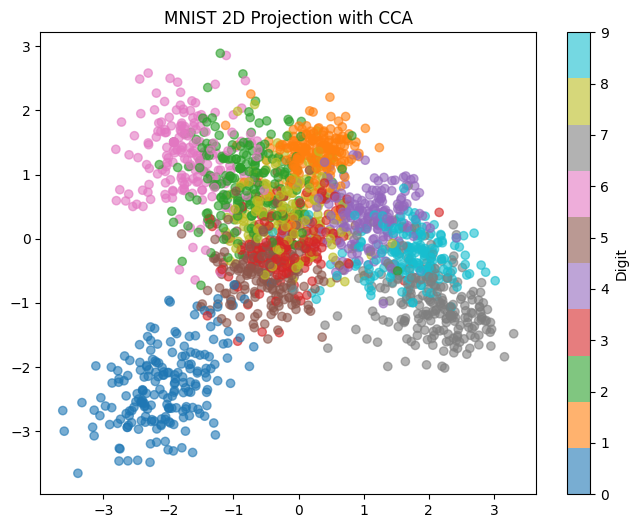

In [4]:
# Select a subset of 2000 img for representation
n_subset=2000
print(f"PCA Plot of a subset of {n_subset} images")
idx = np.random.choice(len(trainset.dataset), size=n_subset, replace=False)
X = torch.stack([trainset.dataset[i][0].view(-1) for i in idx]).numpy()
# code y as one hot for CCA
labels = np.array([trainset.dataset[i][1] for i in idx]).reshape(-1, 1)
one_hot_encoder = OneHotEncoder(sparse_output=False)
y = one_hot_encoder.fit_transform(labels)
print(y.shape)
# Do the CCA
cca = CCA(n_components=2)
X_cca, _ = cca.fit_transform(X, y)

# plot it
plt.figure(figsize=(8,6))
plt.scatter(X_cca[:,0], X_cca[:,1], c=labels.flatten(), cmap='tab10', alpha=0.6)
plt.colorbar(label="Digit")
plt.title("MNIST 2D Projection with CCA")
plt.show()



## Model define

Epoch 1: Train Loss = 0.0059, Test Loss = 0.0000
Epoch 2: Train Loss = 0.0000, Test Loss = 0.0000
Epoch 3: Train Loss = 0.0000, Test Loss = 0.0000
Epoch 4: Train Loss = 0.0000, Test Loss = 0.0000
Epoch 5: Train Loss = 0.0000, Test Loss = 0.0000


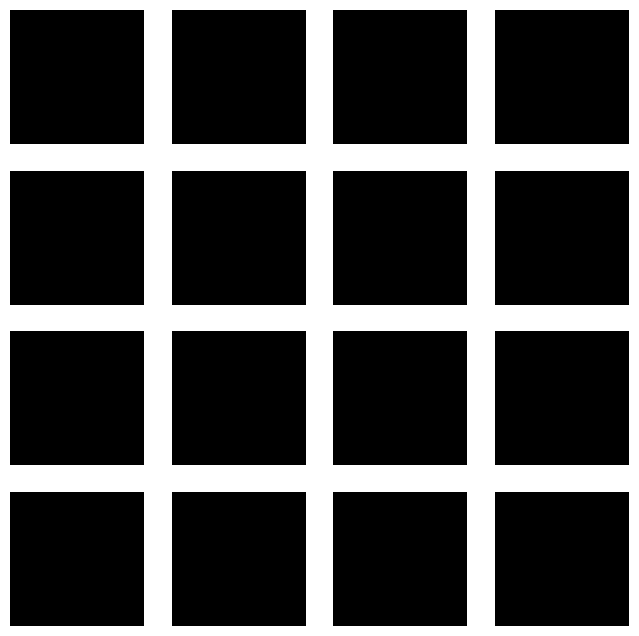

In [7]:
from model import LightMNISTModel, Trainer, SoftmaxCategorical
# ---------------------------
# Uso
# ---------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = LightMNISTModel(hidden_dim=64)
trainer = Trainer(model, trainset, testset, device=device)

# Entrenar 5 epochs
for epoch in range(5):
    train_loss = trainer.train_epoch()
    test_loss = trainer.evaluate()
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}")

# Generar imágenes
samples = trainer.sample_images(n=16)
plt.figure(figsize=(8,8))
for i, img in enumerate(samples):
    plt.subplot(4,4,i+1)
    plt.imshow(img, cmap='gray')  # img ya es (28,28)
    plt.axis('off')
plt.show()